In [40]:
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
movielens = pd.read_csv("data/movielens_cleaned.csv")
print(movielens.head())
print(movielens.shape)

   movieId                        title  year  movielens_rating  \
0        1                    toy story  1995          4.146846   
1        2                      jumanji  1995          3.201141   
2        3             grumpier old men  1995          3.016736   
3        4            waiting to exhale  1995          2.729412   
4        5  father of the bride part ii  1995          3.006757   

   movielens_votes  
0             2077  
1              701  
2              478  
3              170  
4              296  
(3706, 5)


In [43]:
average_rating = movielens["movielens_rating"].mean()
print("Average MovieLens rating:", average_rating)

Average MovieLens rating: 3.2388921779108912


In [44]:
print("Max rating:", movielens["movielens_rating"].max())
print("Min rating:", movielens["movielens_rating"].min())

Max rating: 5.0
Min rating: 1.0


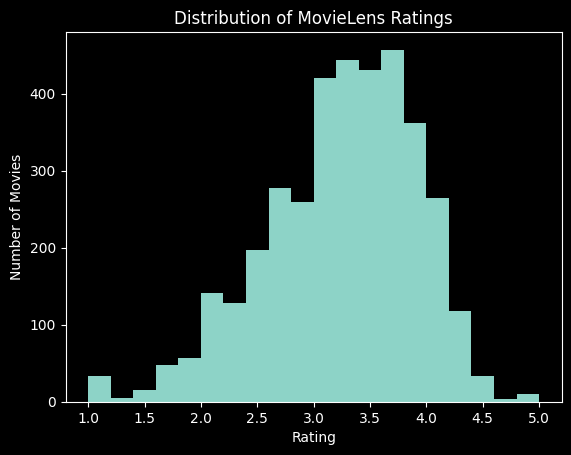

In [45]:
plt.hist(movielens["movielens_rating"], bins=20)

plt.title("Distribution of MovieLens Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")

plt.show()

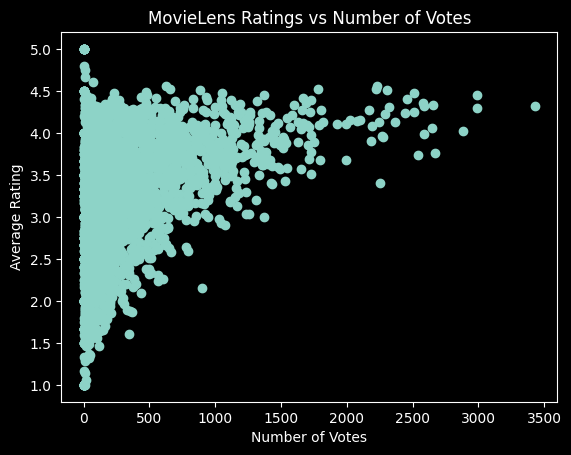

In [46]:
plt.scatter(movielens["movielens_votes"], movielens["movielens_rating"])

plt.title("MovieLens Ratings vs Number of Votes")
plt.xlabel("Number of Votes")
plt.ylabel("Average Rating")

plt.show()

In [47]:
print("Part 1 Finding:")
print("Most MovieLens ratings are concentrated between 3 and 4.")
print("This suggests that users tend to give moderate ratings instead of extreme scores.")

Part 1 Finding:
Most MovieLens ratings are concentrated between 3 and 4.
This suggests that users tend to give moderate ratings instead of extreme scores.


In [11]:
# 2.TMDb rating vs. IMDb rating

In [48]:
tmdb_imdb = pd.read_csv("data/merged_tmdb_imdb.csv")

print(tmdb_imdb.head())
print(tmdb_imdb.shape)

        id                         title  vote_average  vote_count  \
0  1226863  the super mario galaxy movie         6.746         723   
1    10867                        malena         7.400        2491   
2  1198994                     send help         7.000        1182   
3      350         the devil wears prada         7.389       13153   
4  1292695            they will kill you         6.700         343   

  release_date  popularity                genre_ids    year      tconst  \
0   2026-04-01    475.8419  [10751, 35, 12, 14, 16]  2026.0  tt28650488   
1   2000-10-27    324.4101                     [18]  2000.0   tt0213847   
2   2026-01-22    273.8197             [27, 53, 35]  2026.0   tt8036976   
3   2006-06-29    250.2629                 [18, 35]  2006.0   tt0458352   
4   2026-03-25    219.2751             [28, 35, 27]  2026.0  tt31728330   

   imdb_rating  imdb_votes  
0          6.4       35099  
1          7.4      124481  
2          6.9       72667  
3          7

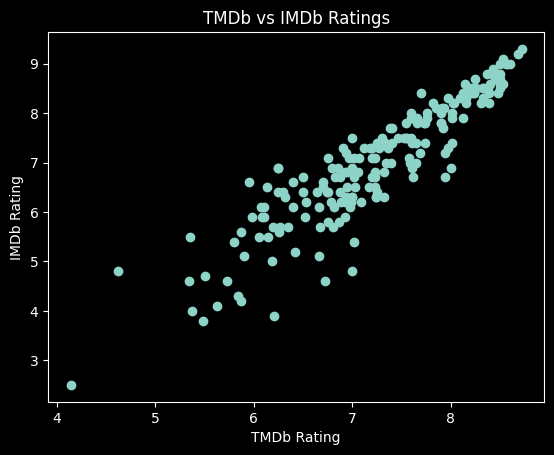

In [49]:
plt.scatter(tmdb_imdb["vote_average"], tmdb_imdb["imdb_rating"])

plt.xlabel("TMDb Rating")
plt.ylabel("IMDb Rating")
plt.title("TMDb vs IMDb Ratings")

plt.show()

In [50]:
correlation = tmdb_imdb["vote_average"].corr(tmdb_imdb["imdb_rating"]) #Pearson correlation
print("Correlation between TMDb and IMDb:", correlation)

Correlation between TMDb and IMDb: 0.9131030198128647


In [51]:
tmdb_imdb["rating_diff"] = tmdb_imdb["vote_average"] - tmdb_imdb["imdb_rating"]

print(tmdb_imdb["rating_diff"].describe())

count    196.000000
mean       0.233423
std        0.584844
min       -0.702000
25%       -0.182500
50%        0.095500
75%        0.613500
max        2.308000
Name: rating_diff, dtype: float64


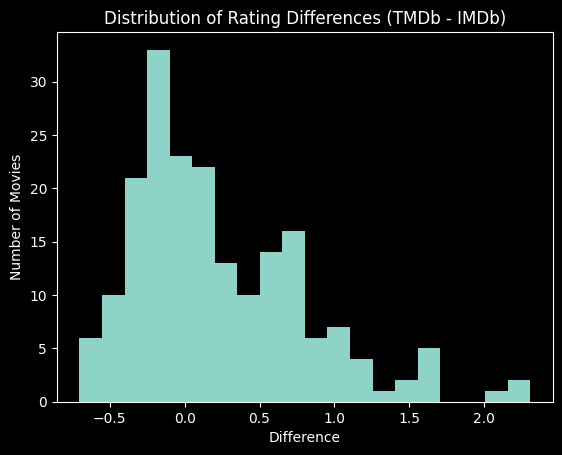

In [52]:
plt.hist(tmdb_imdb["rating_diff"], bins=20)

plt.title("Distribution of Rating Differences (TMDb - IMDb)")
plt.xlabel("Difference")
plt.ylabel("Number of Movies")

plt.show()

In [18]:
# 3.sentiment

In [53]:
from textblob import TextBlob
import pandas as pd

reviews = pd.read_csv("data/tmdb_reviews.csv")

print(reviews.head())

   movie_id                                            content
0   1226863  Full review: https://fandomwire.com/the-super-...
1   1226863  **A film that could have had great potential**...
2   1226863  This movie is stupid trash. You should know th...
3   1226863  YOU KNOW WHAT?\r\nThis movie is good because I...
4   1226863  It was engaging from start to finish.\r\n\r\nM...


In [54]:
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

reviews["sentiment"] = reviews["content"].apply(get_sentiment)

print(reviews.head())

   movie_id                                            content  sentiment
0   1226863  Full review: https://fandomwire.com/the-super-...   0.188932
1   1226863  **A film that could have had great potential**...   0.139815
2   1226863  This movie is stupid trash. You should know th...  -0.000617
3   1226863  YOU KNOW WHAT?\r\nThis movie is good because I...   0.424038
4   1226863  It was engaging from start to finish.\r\n\r\nM...   0.280060


In [55]:
sentiment_by_movie = reviews.groupby("movie_id")["sentiment"].mean().reset_index()

print(sentiment_by_movie.head())

   movie_id  sentiment
0        13   0.738956
1       120   0.187289
2       122   0.176994
3       129   0.263610
4       155   0.231418


In [56]:
review_counts = reviews.groupby("movie_id").size().reset_index(name="review_count")
sentiment_by_movie = reviews.groupby("movie_id")["sentiment"].mean().reset_index()

sentiment_by_movie = pd.merge(sentiment_by_movie, review_counts, on="movie_id")

sentiment_by_movie = sentiment_by_movie[sentiment_by_movie["review_count"] >= 2]

print(sentiment_by_movie.head())
print(sentiment_by_movie.shape)

   movie_id  sentiment  review_count
0        13   0.738956             3
1       120   0.187289            10
2       122   0.176994             7
3       129   0.263610             2
4       155   0.231418            16
(76, 3)


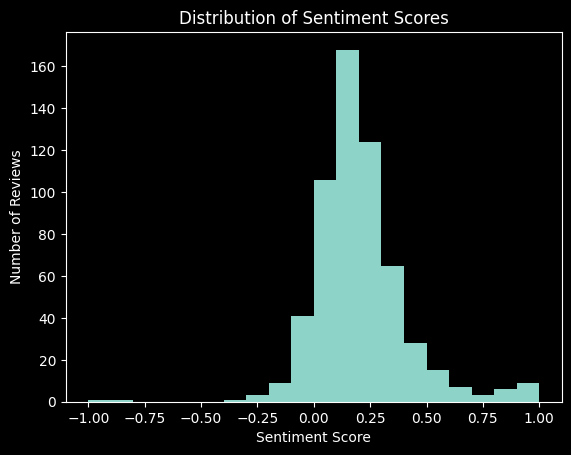

In [57]:
plt.hist(reviews["sentiment"], bins=20)

plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Number of Reviews")

plt.show()

In [58]:
tmdb_imdb = pd.read_csv("data/merged_tmdb_imdb.csv")

final_sentiment = pd.merge(
    tmdb_imdb,
    sentiment_by_movie,
    left_on="id",
    right_on="movie_id"
)

print(final_sentiment.head())
print(final_sentiment.shape)

        id                         title  vote_average  vote_count  \
0  1226863  the super mario galaxy movie         6.746         723   
1  1198994                     send help         7.000        1182   
2      350         the devil wears prada         7.389       13153   
3  1292695            they will kill you         6.700         343   
4  1327819                       hoppers         7.735         722   

  release_date  popularity                 genre_ids    year      tconst  \
0   2026-04-01    475.8419   [10751, 35, 12, 14, 16]  2026.0  tt28650488   
1   2026-01-22    273.8197              [27, 53, 35]  2026.0   tt8036976   
2   2006-06-29    250.2629                  [18, 35]  2006.0   tt0458352   
3   2026-03-25    219.2751              [28, 35, 27]  2026.0  tt31728330   
4   2026-03-04    207.3310  [12, 16, 35, 10751, 878]  2026.0  tt26443616   

   imdb_rating  imdb_votes  movie_id  sentiment  review_count  
0          6.4       35099   1226863   0.193904           

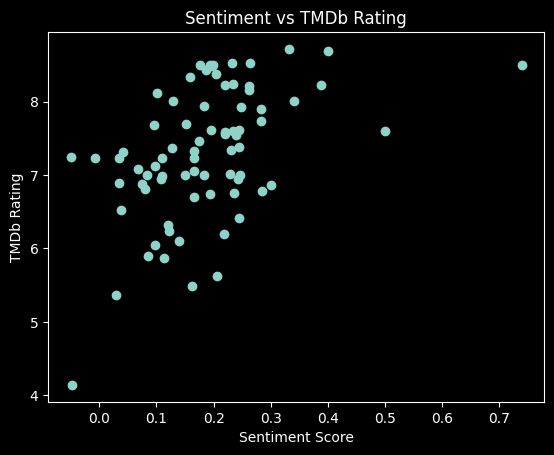

In [59]:
# sentiment vs TMDb
import matplotlib.pyplot as plt

plt.scatter(final_sentiment["sentiment"], final_sentiment["vote_average"])

plt.xlabel("Sentiment Score")
plt.ylabel("TMDb Rating")
plt.title("Sentiment vs TMDb Rating")

plt.show()

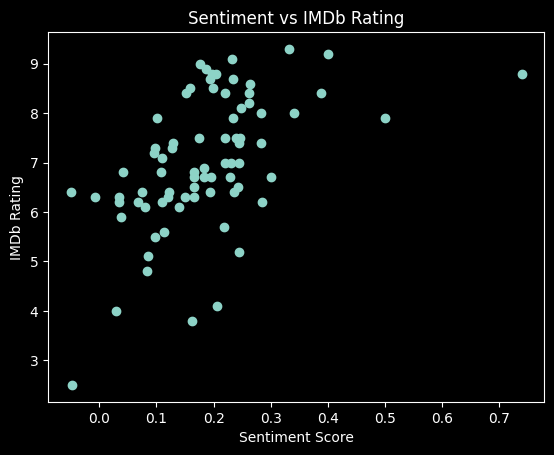

In [60]:
# sentiment vs IMDb
plt.scatter(final_sentiment["sentiment"], final_sentiment["imdb_rating"])

plt.xlabel("Sentiment Score")
plt.ylabel("IMDb Rating")
plt.title("Sentiment vs IMDb Rating")

plt.show()